# EDA: `individual_book_train`

Order book data per stock: two levels of bid/ask **prices** and **sizes**, indexed by `time_id` and `seconds_in_bucket` (0–599 within each bucket).

We load a **subset of rows** per file (full files are large). If prices are stored as **log returns**, a later section rebuilds **nominal bid/ask levels** before plotting mid and spread.

In [20]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 20)

PRICE_COLS = ["bid_price1", "ask_price1", "bid_price2", "ask_price2"]

DATA_DIR = Path("individual_book_train")

# First N rows per stock keeps the notebook fast; increase if you want a longer window.
NROWS = 150_000

# Pick any stock_ids that exist as stock_{id}.csv
STOCK_IDS = [116, 10, 42]

In [21]:
def load_stock(stock_id: int, nrows: int | None = None) -> pd.DataFrame:
    path = DATA_DIR / f"stock_{stock_id}.csv"
    if not path.exists():
        raise FileNotFoundError(path)
    df = pd.read_csv(path, nrows=nrows)
    return df


def log_returns_to_levels(df: pd.DataFrame, base: float = 1.0) -> pd.DataFrame:
    """Treat each price column as a log return r_t; recover levels P_t = base * exp(cumsum r)."""
    out = df.sort_values(["time_id", "seconds_in_bucket"]).reset_index(drop=True)
    for c in PRICE_COLS:
        r = out[c].to_numpy(dtype=np.float64)
        out[c] = base * np.exp(np.cumsum(r))
    return out


def add_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["event_time"] = out["time_id"] * 600 + out["seconds_in_bucket"]
    out["mid"] = (out["bid_price1"] + out["ask_price1"]) / 2.0
    out["spread"] = out["ask_price1"] - out["bid_price1"]
    depth = out["bid_size1"] + out["ask_size1"]
    out["imbalance_l1"] = (out["bid_size1"] - out["ask_size1"]) / depth.replace(0, pd.NA)
    return out


raw_frames = {sid: load_stock(sid, nrows=NROWS) for sid in STOCK_IDS}
frames = {sid: add_features(raw_frames[sid]) for sid in STOCK_IDS}
frames_px = {sid: add_features(log_returns_to_levels(raw_frames[sid])) for sid in STOCK_IDS}

for sid, d in frames.items():
    print(f"stock_{sid}: shape {d.shape}, time_id [{d['time_id'].min()}, {d['time_id'].max()}]")
    print(d.head(3).to_string(), "\n")

stock_116: shape (150000, 15), time_id [5, 4487]
   time_id  seconds_in_bucket  bid_price1  ask_price1  bid_price2  ask_price2  bid_size1  ask_size1  bid_size2  ask_size2  stock_id  event_time       mid    spread  imbalance_l1
0        5                  0    0.996691    0.997544    0.996326    0.997584         55        100         10          1       116        3000  0.997118  0.000853     -0.290323
1        5                  1    0.996691    0.997544    0.996326    0.997625         55          8         10        200       116        3001  0.997118  0.000853      0.746032
2        5                  2    0.996691    0.997544    0.996326    0.997625         55          7         10       1400       116        3002  0.997118  0.000853      0.774194 

stock_10: shape (150000, 15), time_id [5, 2185]
   time_id  seconds_in_bucket  bid_price1  ask_price1  bid_price2  ask_price2  bid_size1  ask_size1  bid_size2  ask_size2  stock_id  event_time       mid    spread  imbalance_l1
0        5 

/var/folders/yr/skjwcgyn0d90_vjgw9zsp_4w0000gn/T/ipykernel_44512/1987966921.py:14: RuntimeWarning: overflow encountered in exp
  out[c] = base * np.exp(np.cumsum(r))
/var/folders/yr/skjwcgyn0d90_vjgw9zsp_4w0000gn/T/ipykernel_44512/1987966921.py:14: RuntimeWarning: overflow encountered in exp
  out[c] = base * np.exp(np.cumsum(r))
/var/folders/yr/skjwcgyn0d90_vjgw9zsp_4w0000gn/T/ipykernel_44512/1987966921.py:14: RuntimeWarning: overflow encountered in exp
  out[c] = base * np.exp(np.cumsum(r))


### Mid & spread in **stored** coordinates (treating columns as-is)

If the CSV stores **log returns** per update, these lines are still the naive mid/spread using raw columns. See the next section for **reconstructed price levels**. X-axis: `event_time` = `time_id` * 600 + `seconds_in_bucket`.

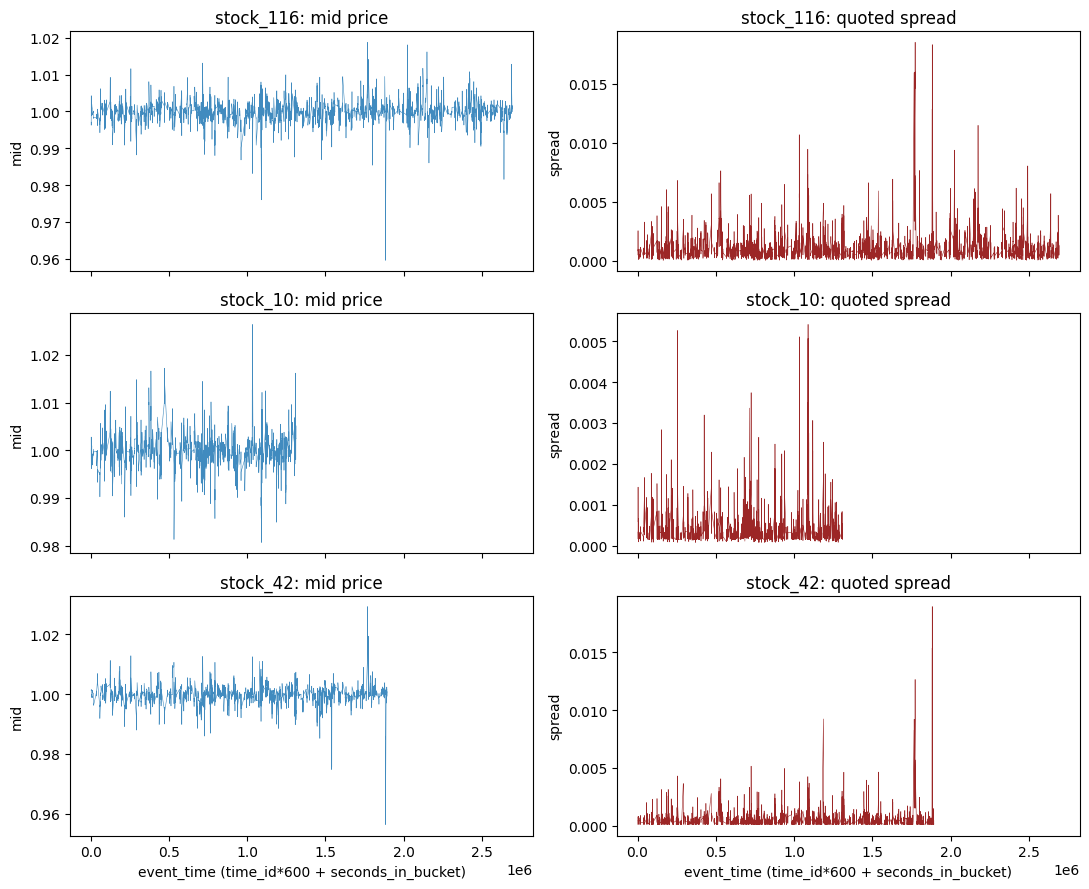

In [22]:
fig, axes = plt.subplots(len(STOCK_IDS), 2, figsize=(11, 3 * len(STOCK_IDS)), sharex="col")
if len(STOCK_IDS) == 1:
    axes = axes.reshape(1, -1)

for ax_mid, ax_sp, sid in zip(axes[:, 0], axes[:, 1], STOCK_IDS, strict=True):
    d = frames[sid].sort_values("event_time")
    ax_mid.plot(d["event_time"], d["mid"], lw=0.4, alpha=0.85)
    ax_mid.set_ylabel("mid")
    ax_mid.set_title(f"stock_{sid}: mid price")

    ax_sp.plot(d["event_time"], d["spread"], lw=0.4, alpha=0.85, color="darkred")
    ax_sp.set_ylabel("spread")
    ax_sp.set_title(f"stock_{sid}: quoted spread")

for ax in axes[-1, :]:
    ax.set_xlabel("event_time (time_id*600 + seconds_in_bucket)")
fig.tight_layout()
plt.show()

### Reconstructed **price levels** (log returns → levels)

Assuming each bid/ask price column holds a **log return** \(r_t\) between consecutive book states (ordered by `time_id`, `seconds_in_bucket`), we recover a nominal price path per side/level with \(P_t = P_0 \exp(\sum_{i \le t} r_i)\). We use \(P_0 = 1\) so the scale is **arbitrary** (relative to the start of the loaded window).

Mid and quoted spread are then computed from these reconstructed bid/ask **levels**.

**Spread distribution** after reconstruction (compare to the earlier histogram in log-return space).

### Spread distribution & level-1 imbalance

Imbalance: \((\text{bid_size}_1 - \text{ask_size}_1) / (\text{bid_size}_1 + \text{ask_size}_1)\), clipped to a sensible y-limit for plotting.

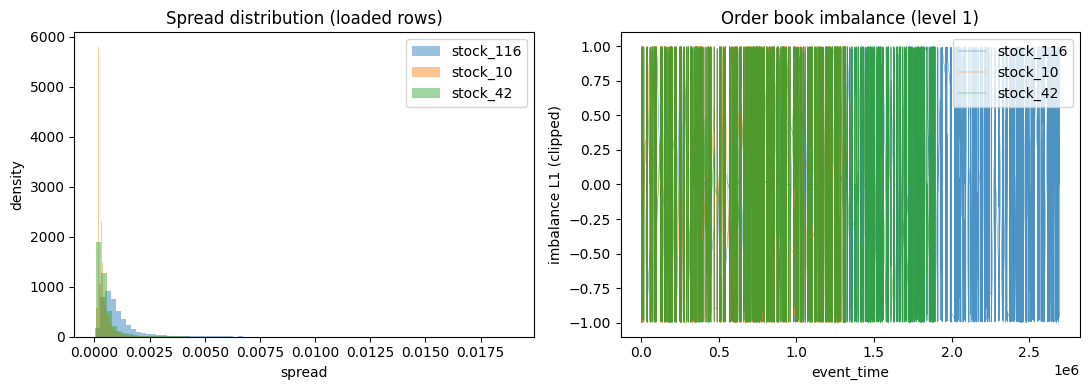

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for sid in STOCK_IDS:
    s = frames[sid]["spread"].dropna()
    axes[0].hist(s, bins=80, density=True, alpha=0.45, label=f"stock_{sid}")
axes[0].set_xlabel("spread")
axes[0].set_ylabel("density")
axes[0].set_title("Spread distribution (loaded rows)")
axes[0].legend()

for sid in STOCK_IDS:
    d = frames[sid].sort_values("event_time").dropna(subset=["imbalance_l1"])
    y = d["imbalance_l1"].clip(-1, 1)
    axes[1].plot(d["event_time"], y, lw=0.35, alpha=0.8, label=f"stock_{sid}")
axes[1].set_xlabel("event_time")
axes[1].set_ylabel("imbalance L1 (clipped)")
axes[1].set_title("Order book imbalance (level 1)")
axes[1].legend()
fig.tight_layout()
plt.show()